<a href="https://colab.research.google.com/github/Praveshika2k/Marketing-Analytics-Project-Coronary-Heart-Disease-CHD-Dataset-/blob/main/Marketing_Analytics_ProjectCode.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Person 1 – EDA & Insights Lead
### Marketing Analytics Project | Coronary Heart Disease (CHD) Dataset
**Goal:** Understand data patterns, visualize distributions, and surface key insights about CHD risk factors.

---
## 📦 Cell 1 — Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot aesthetics
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12



---
## Cell 2 — Load Dataset
> We use the **SMOTE-balanced training set** for EDA so that class imbalance doesn't skew our visual analysis.

In [4]:

df = pd.read_csv('/content/coronary_smote_train.csv')

print(f'Dataset shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Dataset shape: (5754, 16)
Columns: ['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD']


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,0,-0.427442,2,1,0.754417,0,0,0,0,1.273703,-0.048503,0.110514,-1.954869,-0.066032,-0.995681,0
1,0,1.555824,1,0,-0.766423,0,0,0,0,0.326662,-0.702811,-0.677288,0.038298,-0.066032,1.007932,0
2,1,0.972511,1,0,-0.766423,0,0,0,0,-0.383618,0.533104,1.861184,1.079465,-0.066032,0.659477,1
3,1,-0.660768,1,1,2.613220,0,0,0,0,-1.851532,0.896608,0.373114,-1.126131,-0.066032,1.617727,1
4,0,-0.544105,2,0,-0.766423,0,0,1,0,-0.241562,2.326392,1.423516,2.552048,2.560918,-0.124545,0


---
## Cell 3 — Basic Data Overview

In [6]:
print('='*55)
print('DATASET INFO')
print('='*55)
df.info()

print('\n' + '='*55)
print('MISSING VALUES')
print('='*55)
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else 'No missing values')

print('\n' + '='*55)
print('TARGET CLASS DISTRIBUTION')
print('='*55)
print(df['TenYearCHD'].value_counts())
print(f"\nClass balance: {df['TenYearCHD'].value_counts(normalize=True).round(3).to_dict()}")

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5754 entries, 0 to 5753
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             5754 non-null   int64  
 1   age              5754 non-null   float64
 2   education        5754 non-null   int64  
 3   currentSmoker    5754 non-null   int64  
 4   cigsPerDay       5754 non-null   float64
 5   BPMeds           5754 non-null   int64  
 6   prevalentStroke  5754 non-null   int64  
 7   prevalentHyp     5754 non-null   int64  
 8   diabetes         5754 non-null   int64  
 9   totChol          5754 non-null   float64
 10  sysBP            5754 non-null   float64
 11  diaBP            5754 non-null   float64
 12  BMI              5754 non-null   float64
 13  heartRate        5754 non-null   float64
 14  glucose          5754 non-null   float64
 15  TenYearCHD       5754 non-null   int64  
dtypes: float64(8), int64(8)
memory usage: 719.4 KB


---
##  Cell 4 — Statistical Summary

In [7]:
desc = df.describe().T
desc['range'] = desc['max'] - desc['min']
desc.style.background_gradient(cmap='YlOrRd', subset=['mean', 'std', 'range'])

,count,mean,std,min,25%,50%,75%,max,range
male,5754.000000,0.411714,0.492187,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
age,5754.000000,0.238354,0.975297,-2.060721,-0.544105,0.258417,1.069426,2.372464,4.433185
education,5754.000000,1.837331,1.000412,1.000000,1.000000,1.000000,2.000000,4.000000,3.000000
currentSmoker,5754.000000,0.477928,0.499556,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
cigsPerDay,5754.000000,0.045234,1.020548,-0.766423,-0.766423,-0.681932,0.923399,3.458131,4.224553
BPMeds,5754.000000,0.024331,0.154088,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
prevalentStroke,5754.000000,0.003997,0.063103,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
prevalentHyp,5754.000000,0.360792,0.480272,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
diabetes,5754.000000,0.023636,0.151925,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
totChol,5754.000000,0.079091,0.973141,-2.703868,-0.597549,0.018874,0.683240,2.599560,5.303428


---
##  Cell 5 — Target Variable Distribution (CHD vs No CHD)

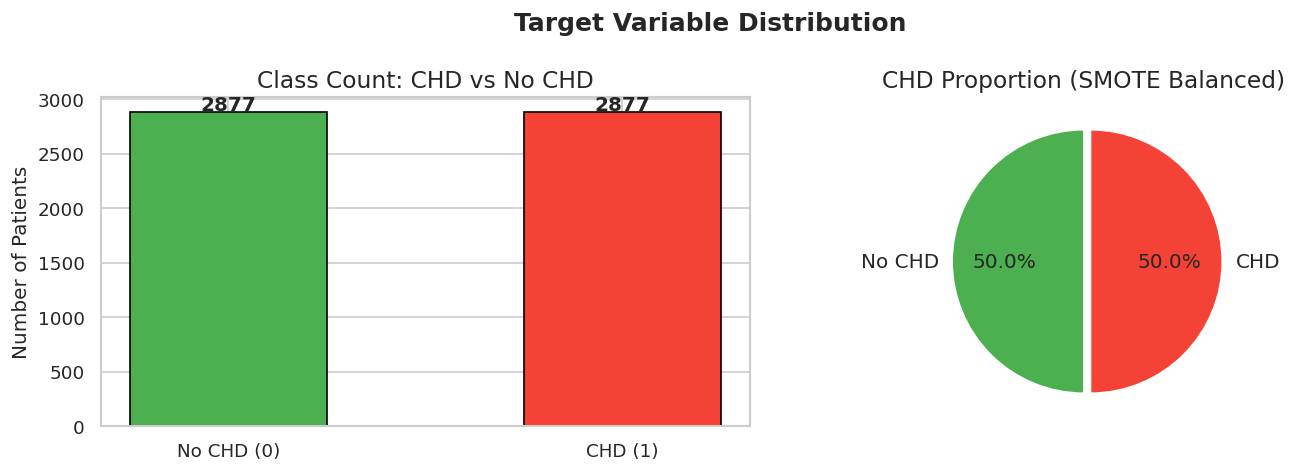

 Note: SMOTE has balanced the dataset — equal CHD and No-CHD cases.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
chd_counts = df['TenYearCHD'].value_counts()
colors = ['#4CAF50', '#F44336']
axes[0].bar(['No CHD (0)', 'CHD (1)'], chd_counts.values, color=colors, edgecolor='black', width=0.5)
for i, v in enumerate(chd_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('Class Count: CHD vs No CHD')
axes[0].set_ylabel('Number of Patients')

# Pie chart
axes[1].pie(chd_counts.values, labels=['No CHD', 'CHD'], autopct='%1.1f%%',
            colors=colors, startangle=90, explode=(0, 0.05),
            textprops={'fontsize': 12})
axes[1].set_title('CHD Proportion (SMOTE Balanced)')

plt.suptitle('Target Variable Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plot1_target_distribution.png', bbox_inches='tight')
plt.show()
print(' Note: SMOTE has balanced the dataset — equal CHD and No-CHD cases.')

---
## Cell 6 — Univariate Analysis: Histograms (Continuous Features)
> Features are scaled (standardized), so values around 0 are typical/average.

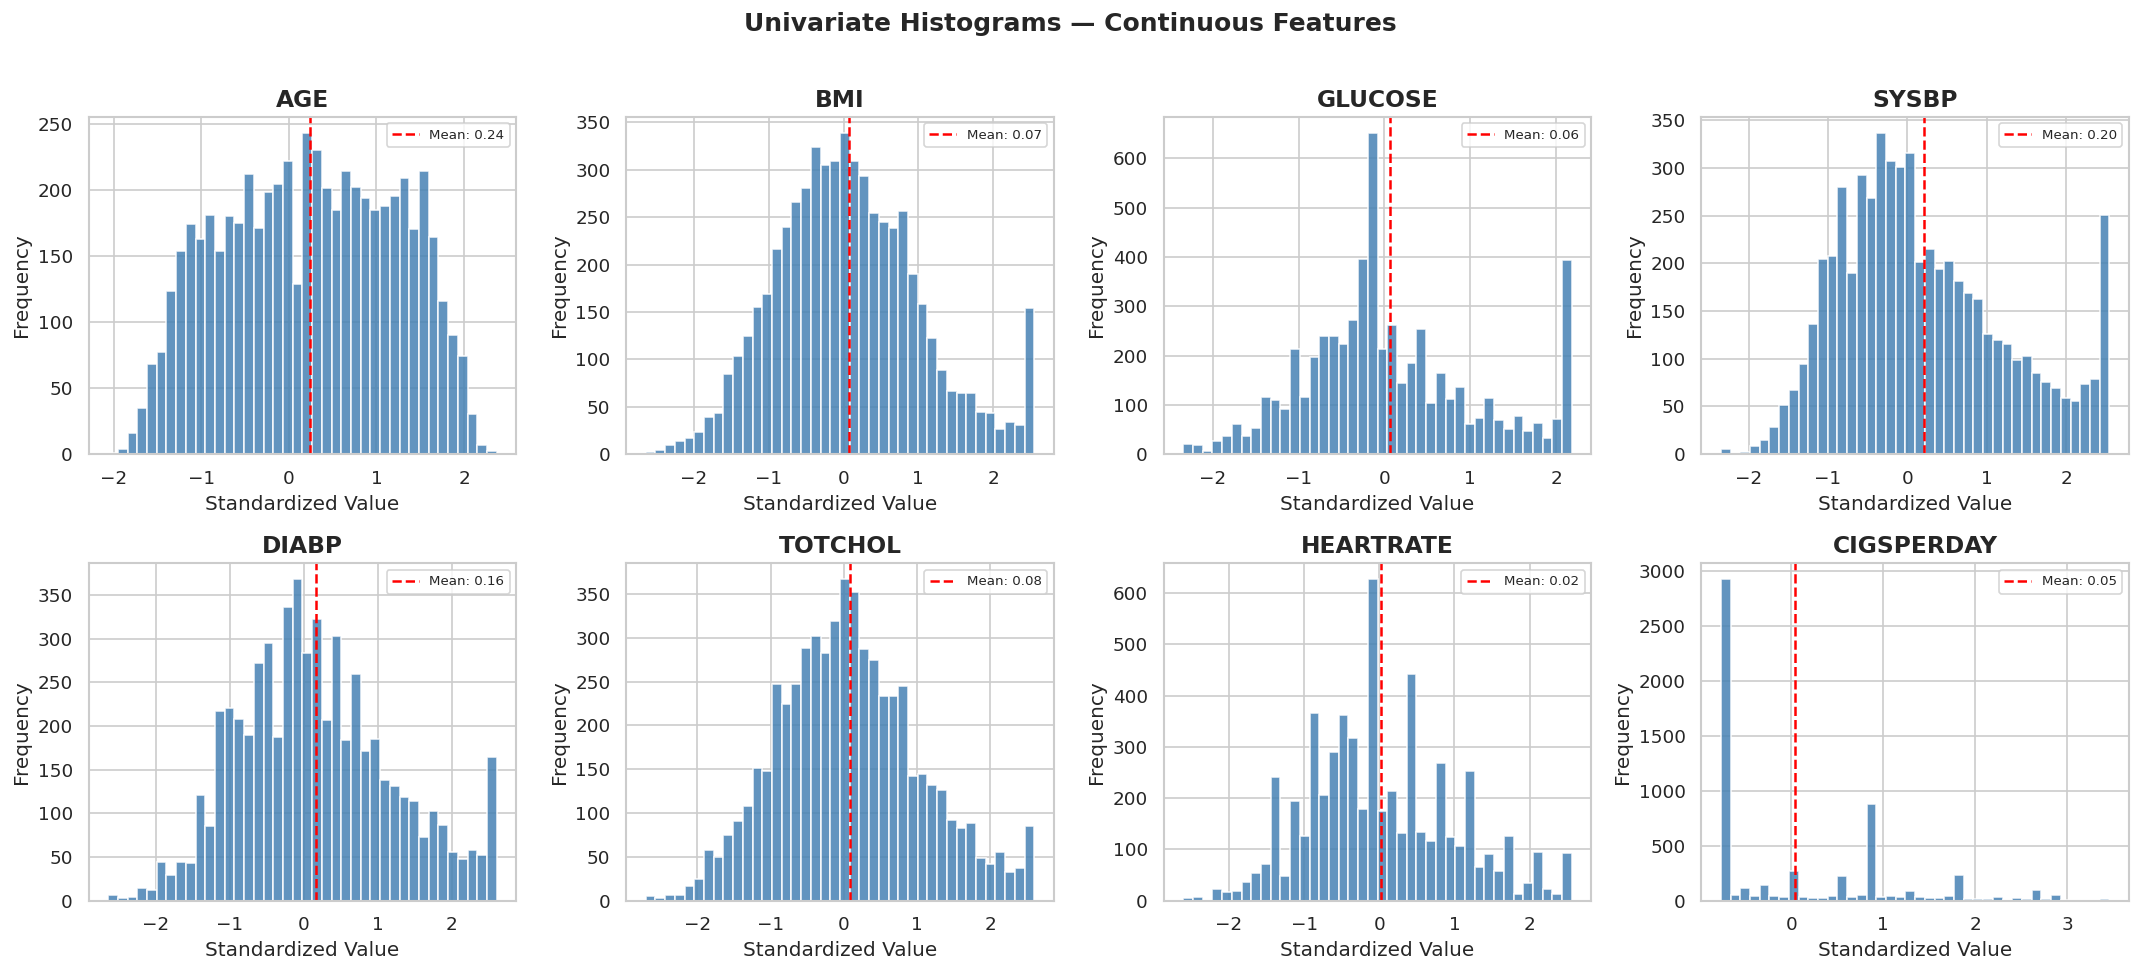

In [9]:
continuous_cols = ['age', 'BMI', 'glucose', 'sysBP', 'diaBP', 'totChol', 'heartRate', 'cigsPerDay']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    axes[i].hist(df[col], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {df[col].mean():.2f}')
    axes[i].set_title(col.upper(), fontweight='bold')
    axes[i].set_xlabel('Standardized Value')
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=8)

plt.suptitle('Univariate Histograms — Continuous Features', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot2_histograms.png', bbox_inches='tight')
plt.show()

---
## Cell 7 — Univariate Analysis: Boxplots (Outlier Detection)

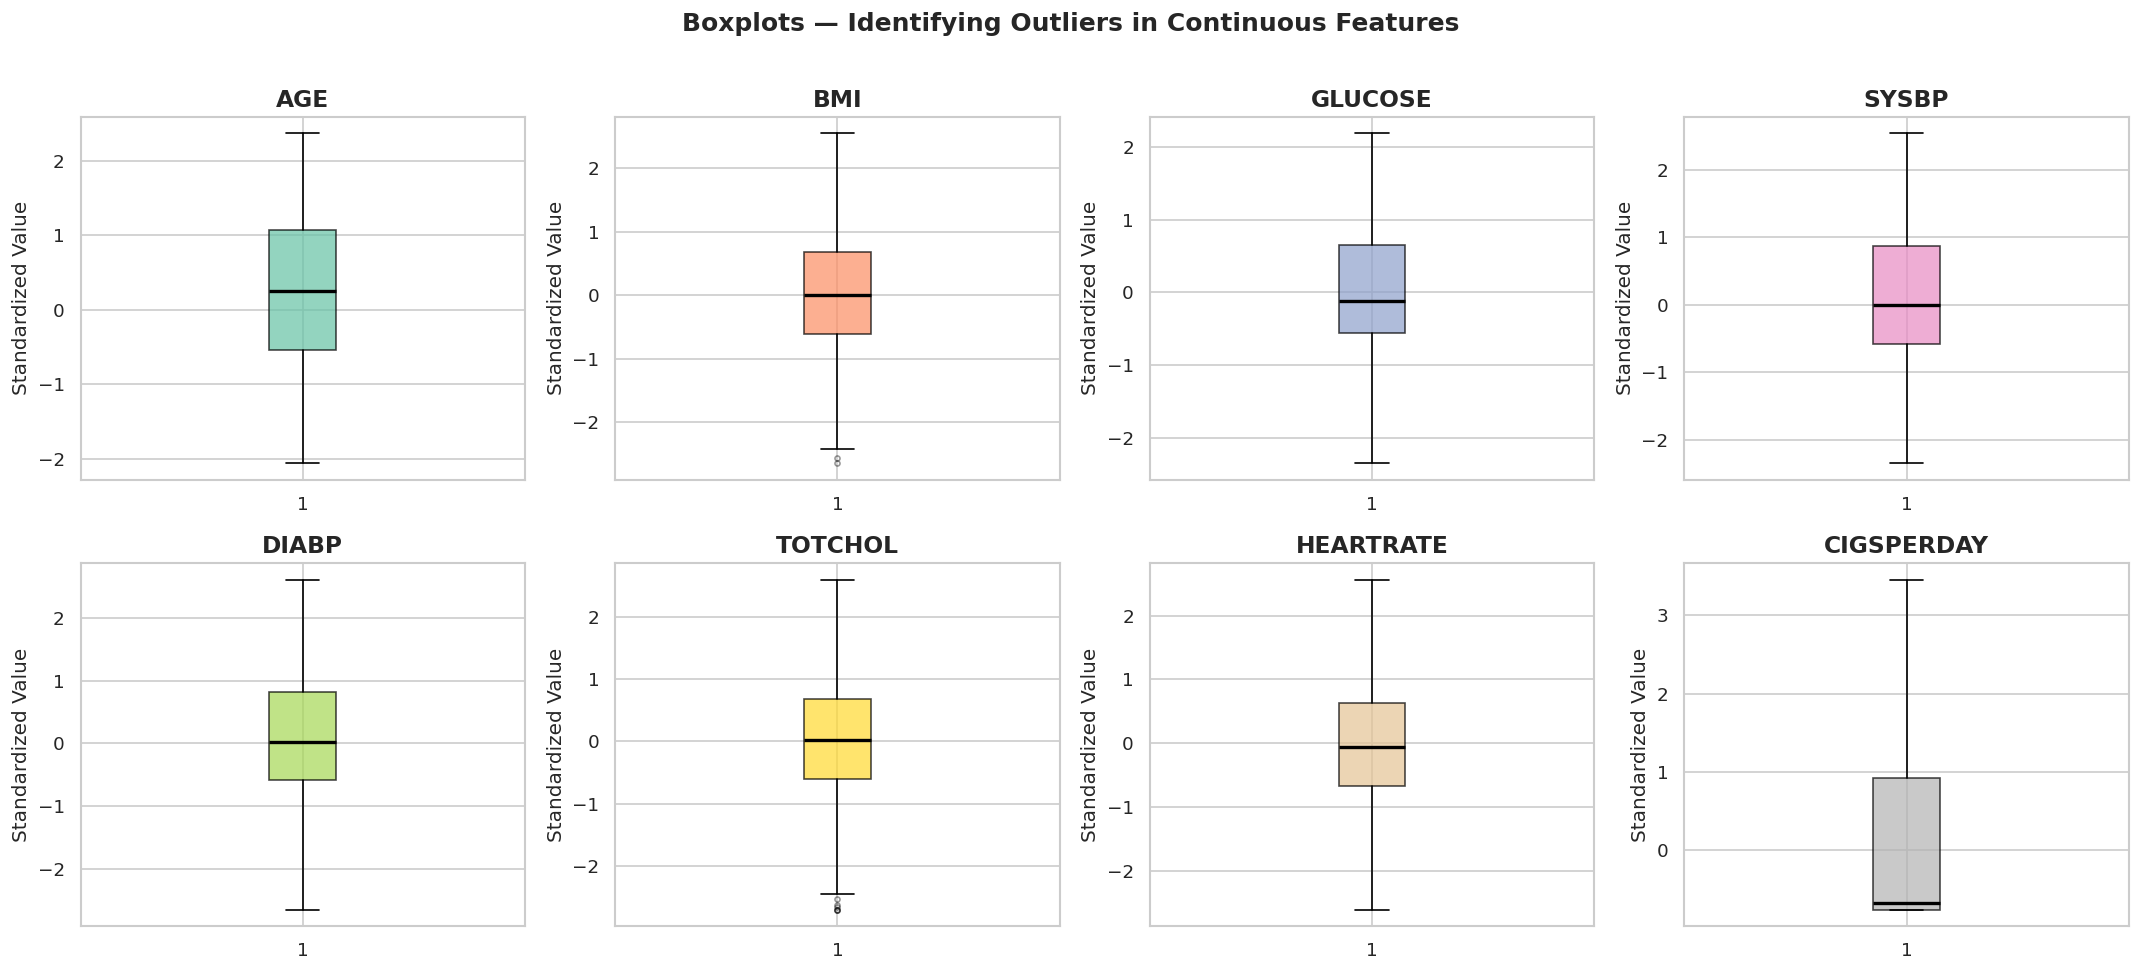

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

palette = sns.color_palette('Set2', len(continuous_cols))

for i, col in enumerate(continuous_cols):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor=palette[i], alpha=0.7),
                    medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(marker='o', color='red', markersize=3, alpha=0.4))
    axes[i].set_title(col.upper(), fontweight='bold')
    axes[i].set_ylabel('Standardized Value')

plt.suptitle('Boxplots — Identifying Outliers in Continuous Features', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot3_boxplots.png', bbox_inches='tight')
plt.show()

---
## Cell 8 — Univariate Analysis: Categorical Features

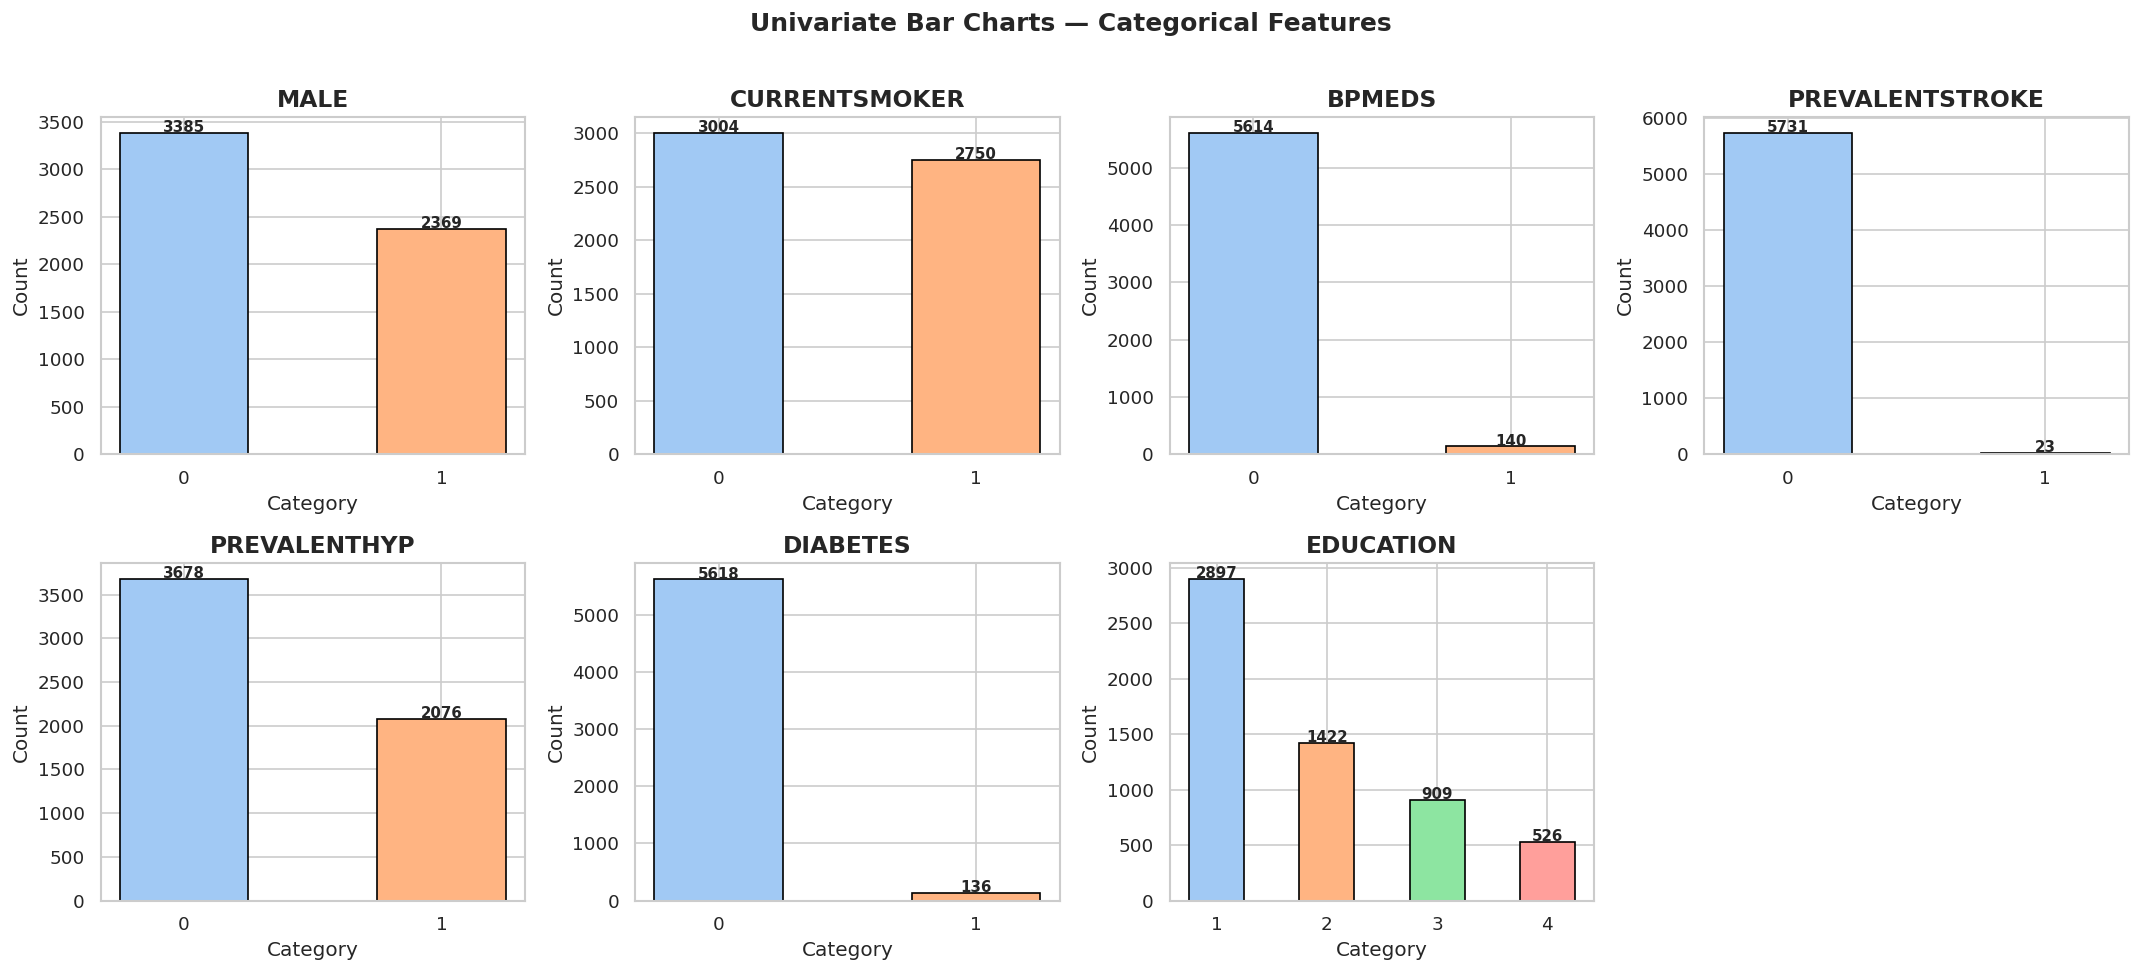

In [11]:
categorical_cols = ['male', 'currentSmoker', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'education']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    counts = df[col].value_counts().sort_index()
    axes[i].bar(counts.index.astype(str), counts.values,
                color=sns.color_palette('pastel', len(counts)),
                edgecolor='black', width=0.5)
    for j, v in enumerate(counts.values):
        axes[i].text(j, v + 10, str(v), ha='center', fontsize=9, fontweight='bold')
    axes[i].set_title(col.upper(), fontweight='bold')
    axes[i].set_xlabel('Category')
    axes[i].set_ylabel('Count')

# Hide unused subplot
axes[-1].set_visible(False)

plt.suptitle('Univariate Bar Charts — Categorical Features', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot4_categorical_counts.png', bbox_inches='tight')
plt.show()

---
## Cell 9 — Bivariate Analysis: Continuous Features vs CHD (Boxplots)

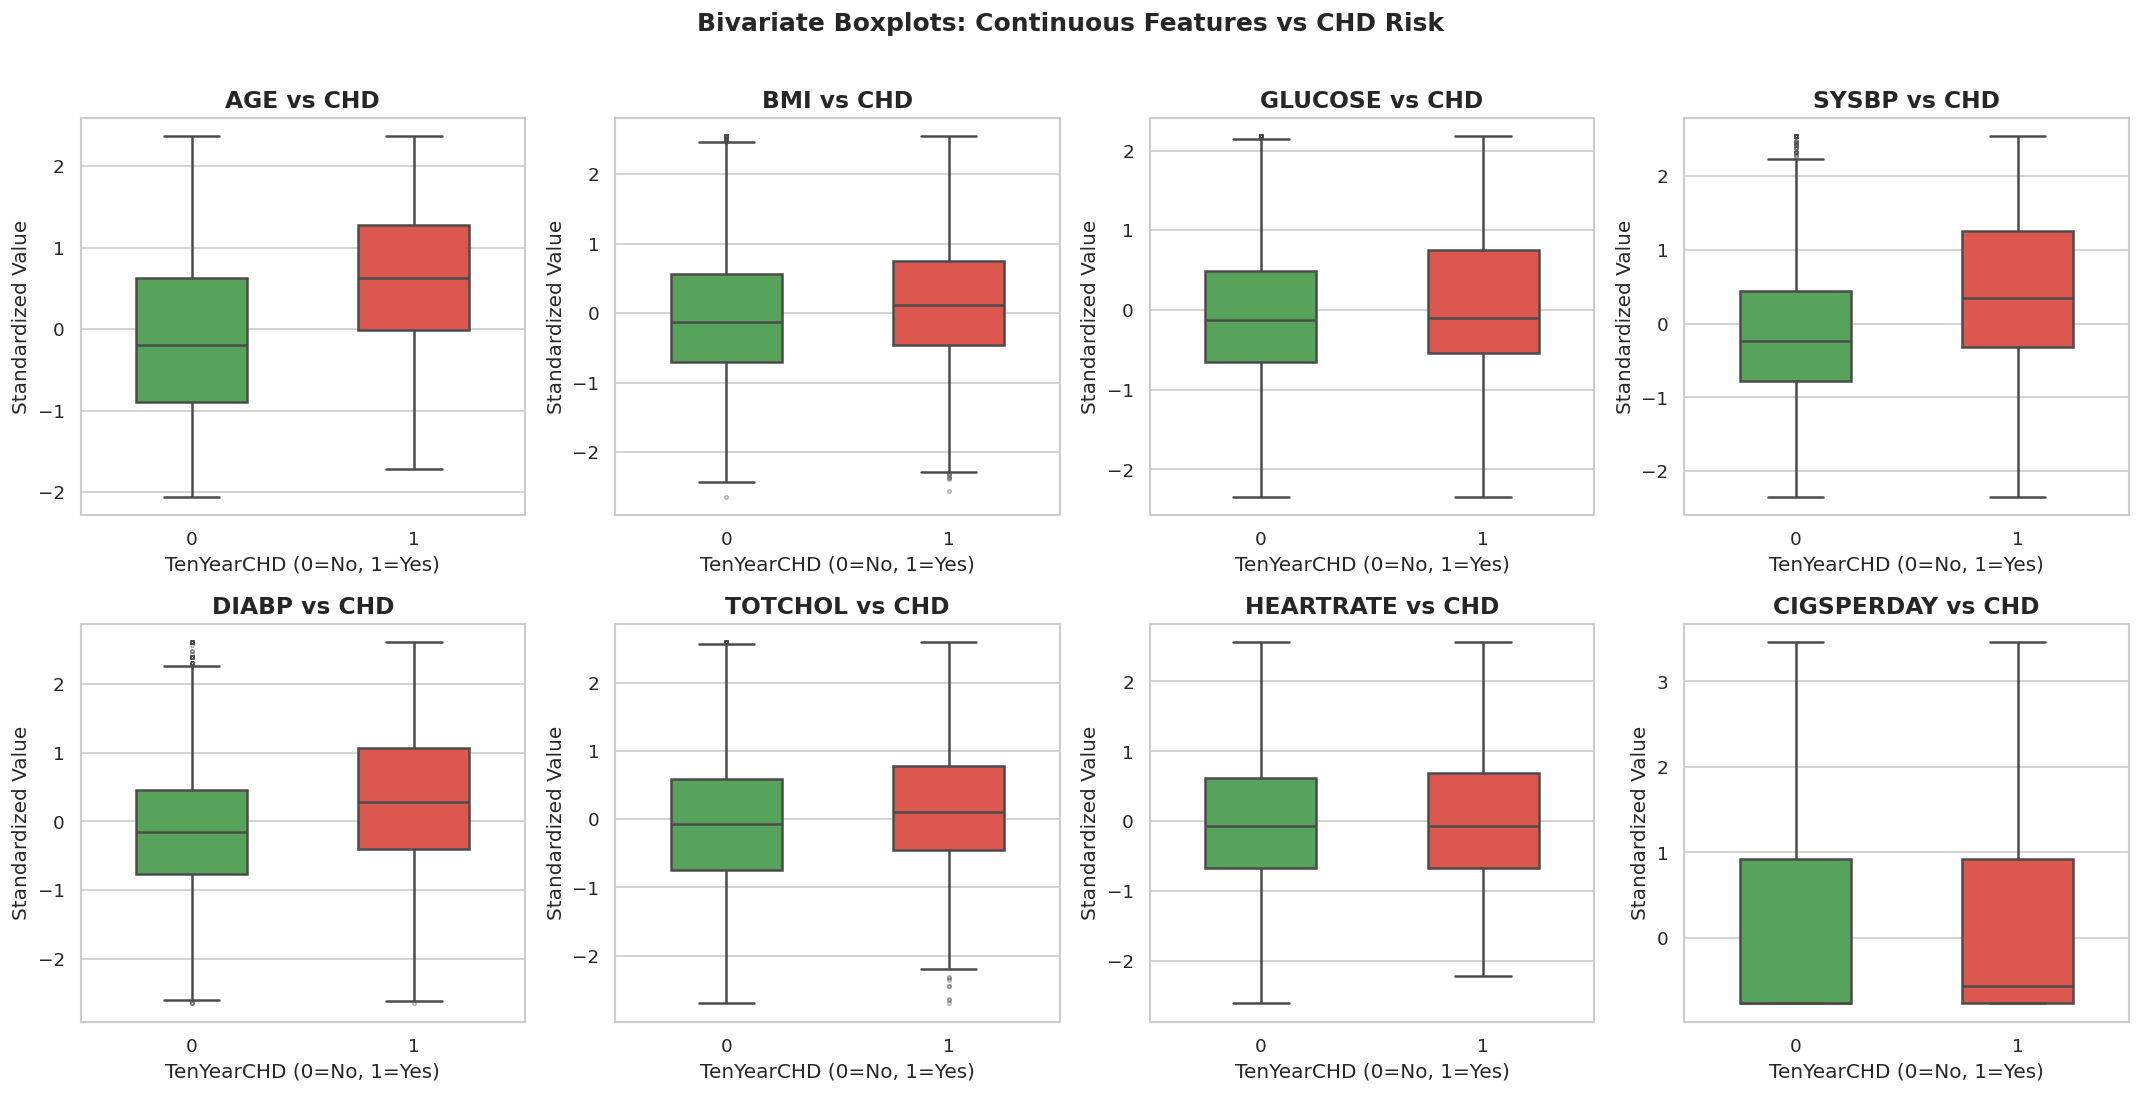

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    sns.boxplot(x='TenYearCHD', y=col, data=df, ax=axes[i],
                hue='TenYearCHD',                        # fix FutureWarning
                palette={0: '#4CAF50', 1: '#F44336'},
                width=0.5, linewidth=1.5, legend=False,  # suppress legend
                flierprops=dict(marker='o', markersize=2, alpha=0.4))
    axes[i].set_title(f'{col.upper()} vs CHD', fontweight='bold')
    axes[i].set_xlabel('TenYearCHD (0=No, 1=Yes)')
    axes[i].set_ylabel('Standardized Value')

plt.suptitle('Bivariate Boxplots: Continuous Features vs CHD Risk', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot5_bivariate_boxplots.png', bbox_inches='tight')
plt.show()

---
## Cell 10 — Bivariate Analysis: Categorical Features vs CHD (Stacked %)

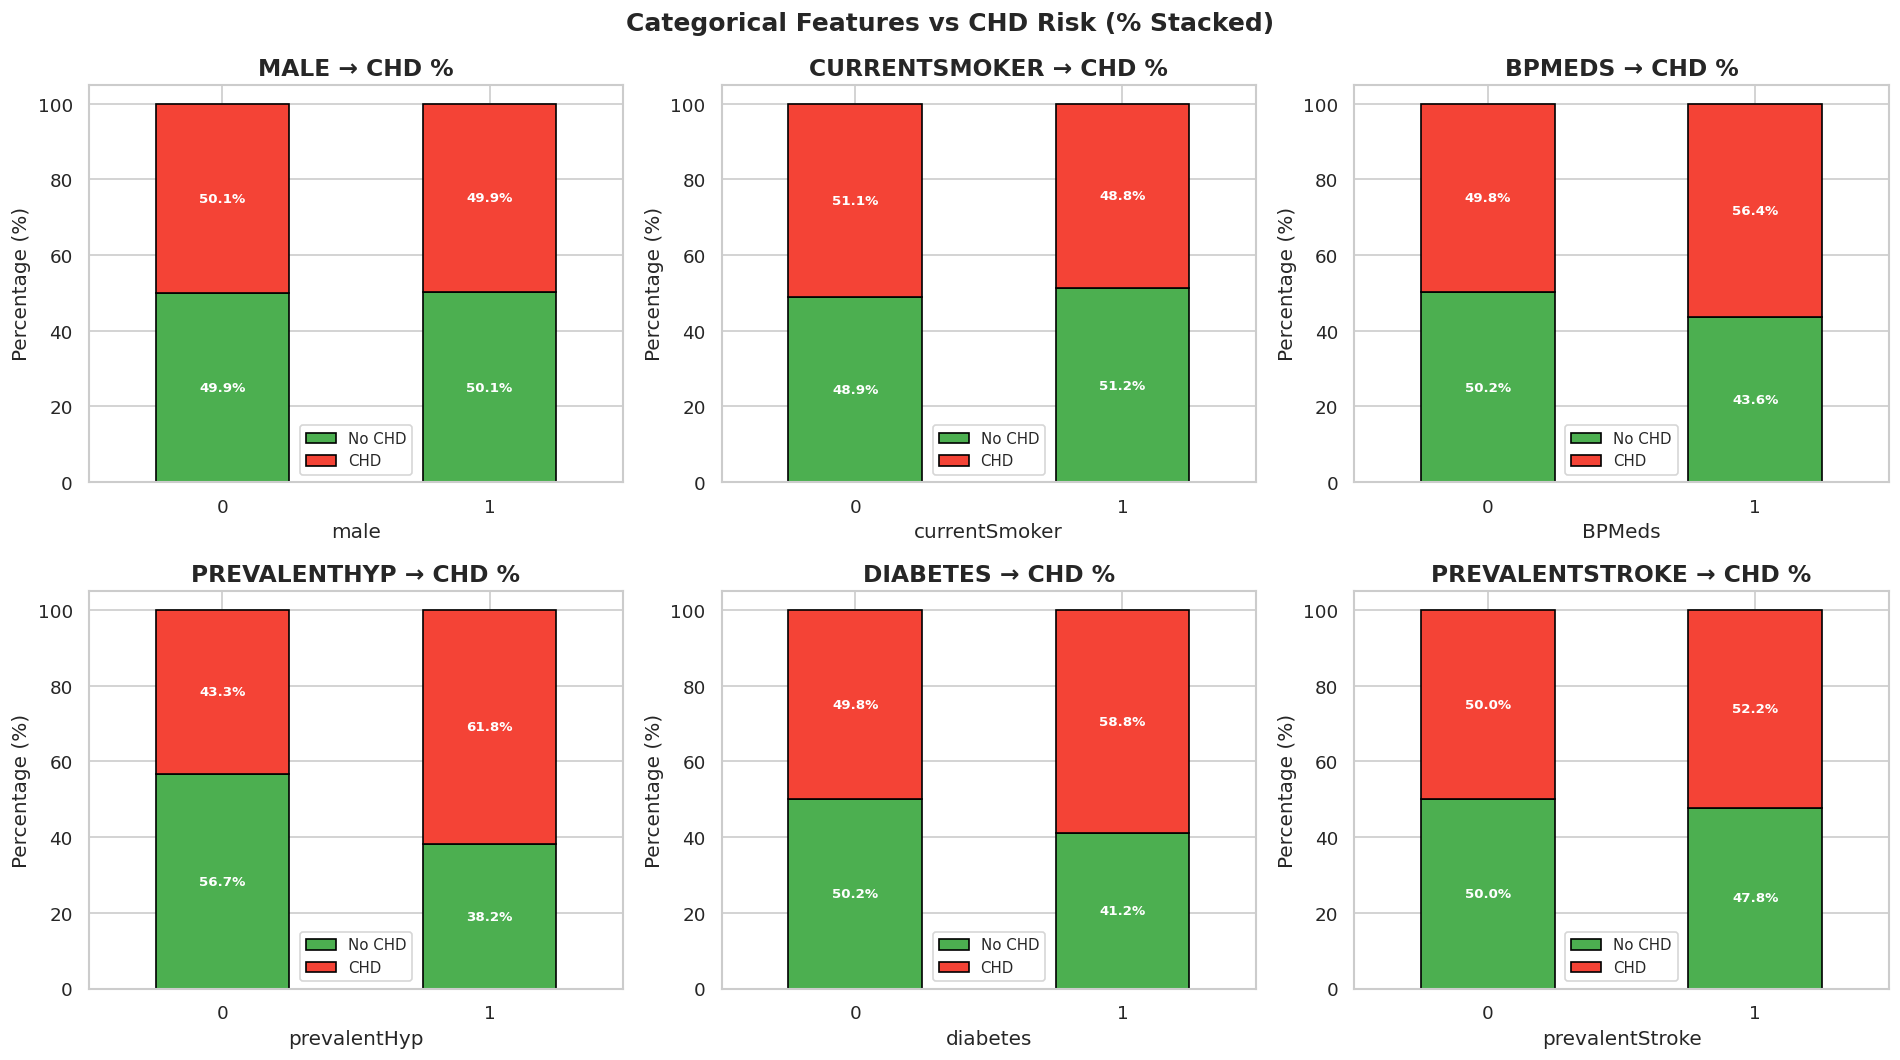

In [14]:
cat_risk_cols = ['male', 'currentSmoker', 'BPMeds', 'prevalentHyp', 'diabetes', 'prevalentStroke']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(cat_risk_cols):
    cross = pd.crosstab(df[col], df['TenYearCHD'], normalize='index') * 100
    cross.columns = ['No CHD', 'CHD']
    cross.plot(kind='bar', stacked=True, ax=axes[i],
               color=['#4CAF50', '#F44336'], edgecolor='black',
               width=0.5)
    axes[i].set_title(f'{col.upper()} → CHD %', fontweight='bold')
    axes[i].set_ylabel('Percentage (%)')
    axes[i].set_xlabel(col)
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=0)
    axes[i].legend(fontsize=9)
    # Annotate CHD %
    for p in axes[i].patches:
        height = p.get_height()
        if height > 5:
            axes[i].text(p.get_x() + p.get_width()/2, p.get_y() + height/2,
                         f'{height:.1f}%', ha='center', va='center',
                         fontsize=8, color='white', fontweight='bold')

plt.suptitle('Categorical Features vs CHD Risk (% Stacked)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plot6_categorical_vs_chd.png', bbox_inches='tight')
plt.show()

---
## Cell 11 — Correlation Heatmap

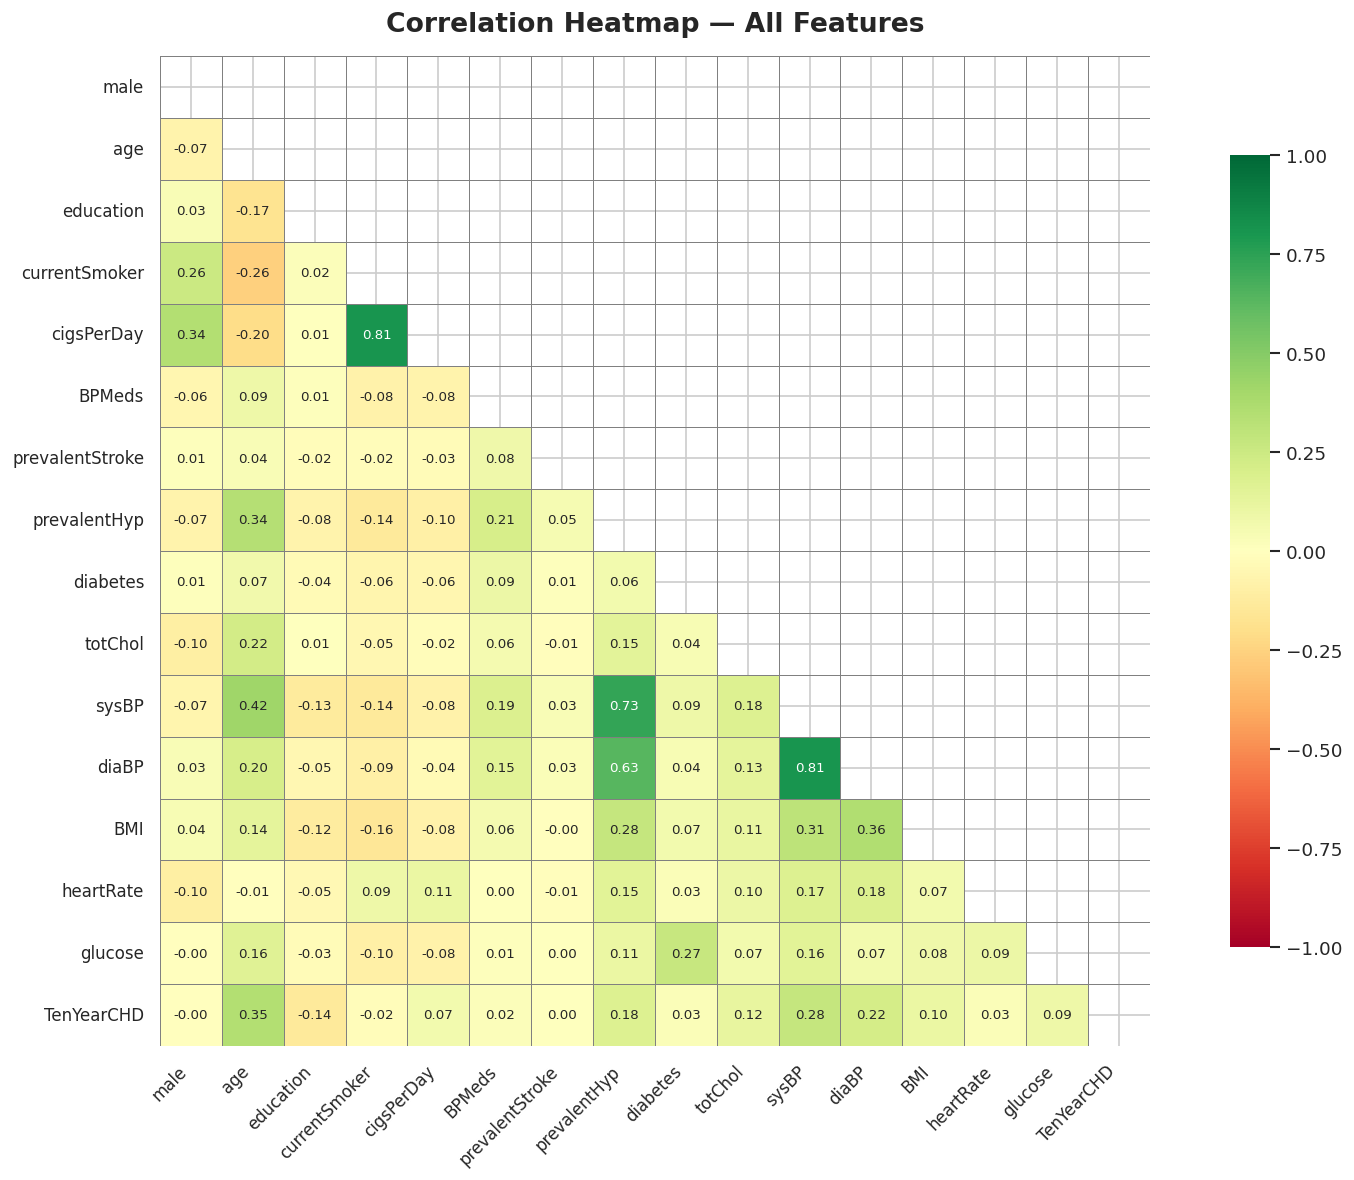


 Top correlations with TenYearCHD:
age                0.348
sysBP              0.281
diaBP              0.216
prevalentHyp       0.178
education         -0.140
totChol            0.119
BMI                0.105
glucose            0.089
cigsPerDay         0.066
heartRate          0.029
diabetes           0.027
currentSmoker     -0.023
BPMeds             0.020
prevalentStroke    0.003
male              -0.002
Name: TenYearCHD, dtype: float64


In [15]:
plt.figure(figsize=(14, 10))

corr = df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))  # upper triangle mask

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    linecolor='gray',
    square=True,
    annot_kws={'size': 8},
    vmin=-1, vmax=1,
    cbar_kws={'shrink': 0.8}
)

plt.title('Correlation Heatmap — All Features', fontsize=16, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig('plot7_correlation_heatmap.png', bbox_inches='tight')
plt.show()

# Top correlations with CHD
print('\n Top correlations with TenYearCHD:')
chd_corr = corr['TenYearCHD'].drop('TenYearCHD').sort_values(key=abs, ascending=False)
print(chd_corr.round(3))

---
## Cell 12 — Smoking & CHD: Detailed Look

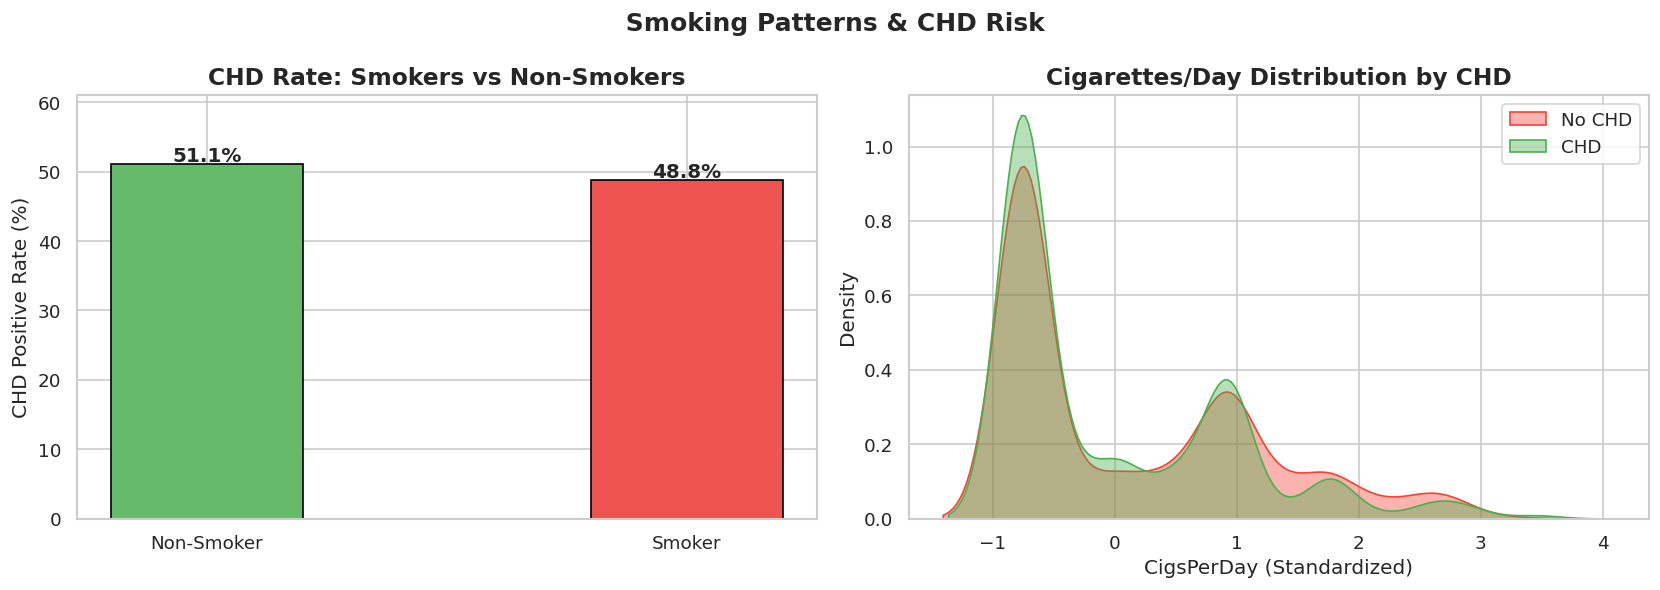

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Smoker vs CHD rate
smoke_chd = df.groupby('currentSmoker')['TenYearCHD'].mean() * 100
axes[0].bar(['Non-Smoker', 'Smoker'], smoke_chd.values,
            color=['#66BB6A', '#EF5350'], edgecolor='black', width=0.4)
for j, v in enumerate(smoke_chd.values):
    axes[0].text(j, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('CHD Rate: Smokers vs Non-Smokers', fontweight='bold')
axes[0].set_ylabel('CHD Positive Rate (%)')
axes[0].set_ylim(0, smoke_chd.max() + 10)

# CigsPerDay vs CHD (distribution)
sns.kdeplot(data=df, x='cigsPerDay', hue='TenYearCHD',
            palette={0: '#4CAF50', 1: '#F44336'},
            fill=True, alpha=0.4, ax=axes[1],
            common_norm=False)
axes[1].set_title('Cigarettes/Day Distribution by CHD', fontweight='bold')
axes[1].set_xlabel('CigsPerDay (Standardized)')
axes[1].legend(labels=['No CHD', 'CHD'])

plt.suptitle(' Smoking Patterns & CHD Risk', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plot8_smoking_chd.png', bbox_inches='tight')
plt.show()

---
## Cell 13 — BP, Diabetes & Cholesterol vs CHD

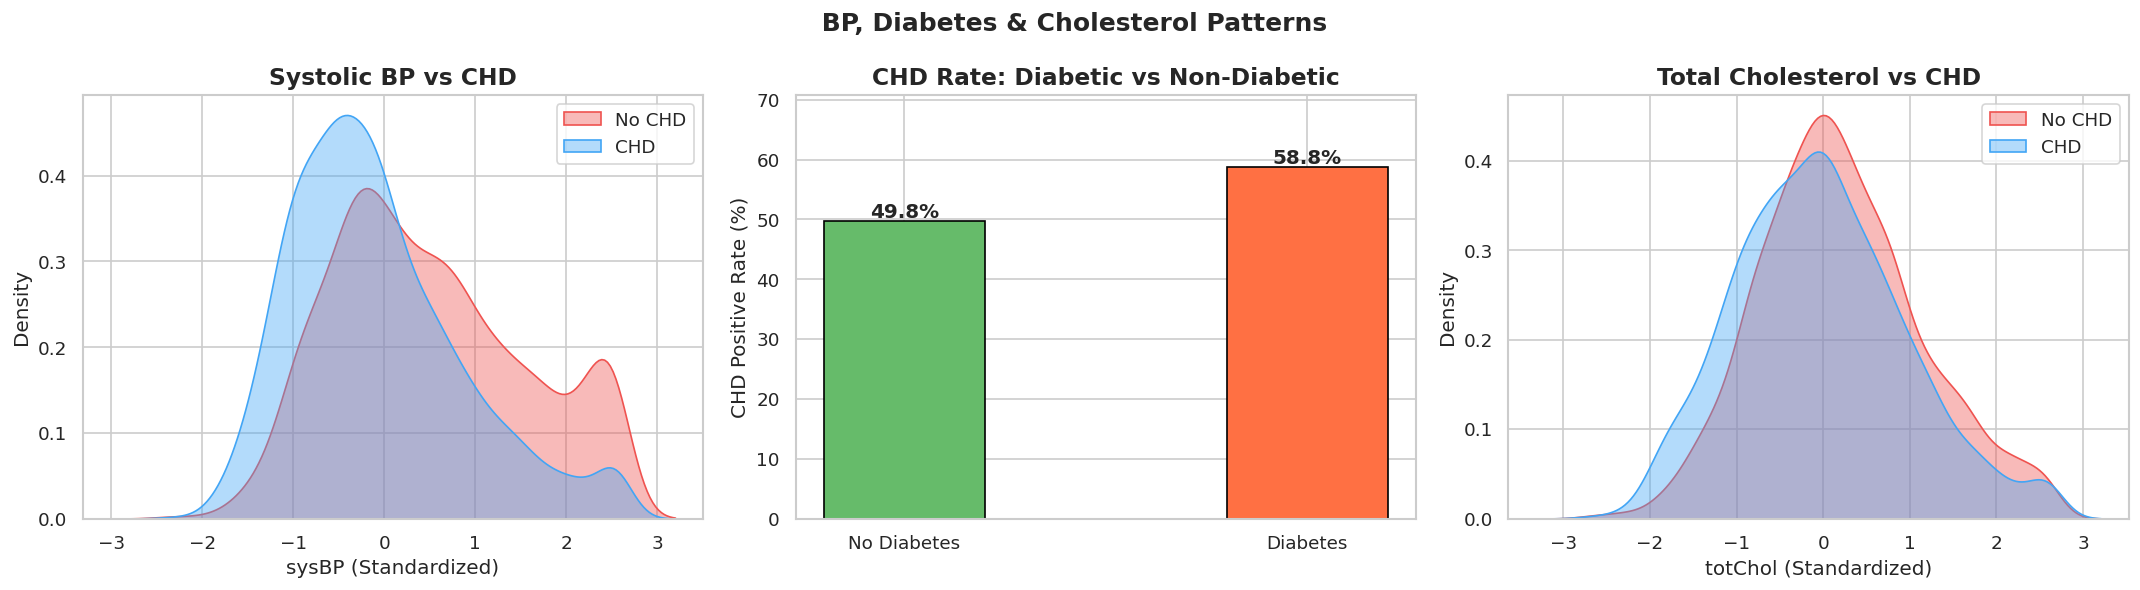

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# sysBP vs CHD
sns.kdeplot(data=df, x='sysBP', hue='TenYearCHD',
            palette={0: '#42A5F5', 1: '#EF5350'},
            fill=True, alpha=0.4, ax=axes[0], common_norm=False)
axes[0].set_title('Systolic BP vs CHD', fontweight='bold')
axes[0].set_xlabel('sysBP (Standardized)')
axes[0].legend(labels=['No CHD', 'CHD'])

# Diabetes vs CHD
dia_chd = df.groupby('diabetes')['TenYearCHD'].mean() * 100
axes[1].bar(['No Diabetes', 'Diabetes'], dia_chd.values,
            color=['#66BB6A', '#FF7043'], edgecolor='black', width=0.4)
for j, v in enumerate(dia_chd.values):
    axes[1].text(j, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=12)
axes[1].set_title('CHD Rate: Diabetic vs Non-Diabetic', fontweight='bold')
axes[1].set_ylabel('CHD Positive Rate (%)')
axes[1].set_ylim(0, dia_chd.max() + 12)

# TotChol vs CHD
sns.kdeplot(data=df, x='totChol', hue='TenYearCHD',
            palette={0: '#42A5F5', 1: '#EF5350'},
            fill=True, alpha=0.4, ax=axes[2], common_norm=False)
axes[2].set_title('Total Cholesterol vs CHD', fontweight='bold')
axes[2].set_xlabel('totChol (Standardized)')
axes[2].legend(labels=['No CHD', 'CHD'])

plt.suptitle(' BP, Diabetes & Cholesterol Patterns', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plot9_bp_diabetes_chol.png', bbox_inches='tight')
plt.show()

---
## Cell 14 — Age & BMI: Distribution by CHD

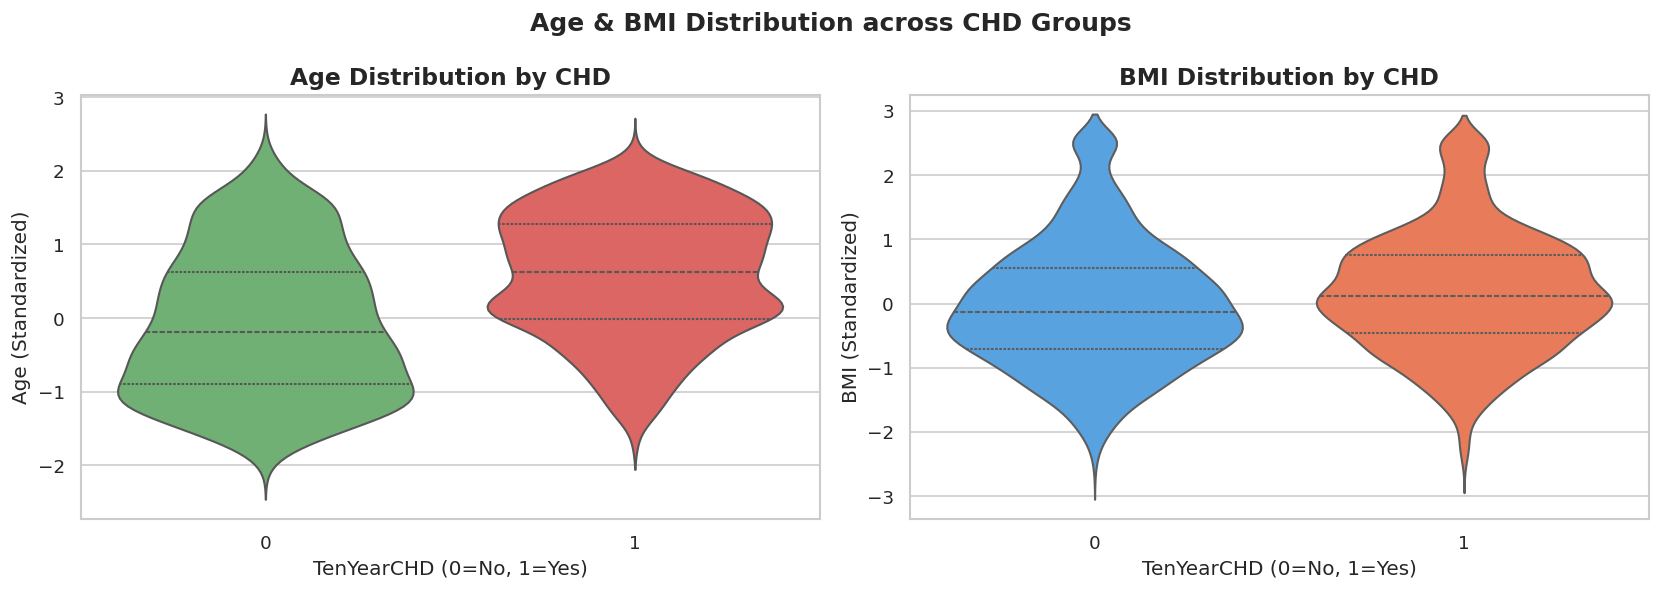

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age
sns.violinplot(data=df, x='TenYearCHD', y='age',
               hue='TenYearCHD', palette={0:'#66BB6A', 1:'#EF5350'},
               inner='quartile', legend=False, ax=axes[0])
axes[0].set_title('Age Distribution by CHD', fontweight='bold')
axes[0].set_xlabel('TenYearCHD (0=No, 1=Yes)')
axes[0].set_ylabel('Age (Standardized)')

# BMI
sns.violinplot(data=df, x='TenYearCHD', y='BMI',
               hue='TenYearCHD', palette={0:'#42A5F5', 1:'#FF7043'},
               inner='quartile', legend=False, ax=axes[1])
axes[1].set_title('BMI Distribution by CHD', fontweight='bold')
axes[1].set_xlabel('TenYearCHD (0=No, 1=Yes)')
axes[1].set_ylabel('BMI (Standardized)')

plt.suptitle('Age & BMI Distribution across CHD Groups', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plot10_age_bmi_violin.png', bbox_inches='tight')
plt.show()

---
## Cell 15 — Pairplot: Key Features vs CHD

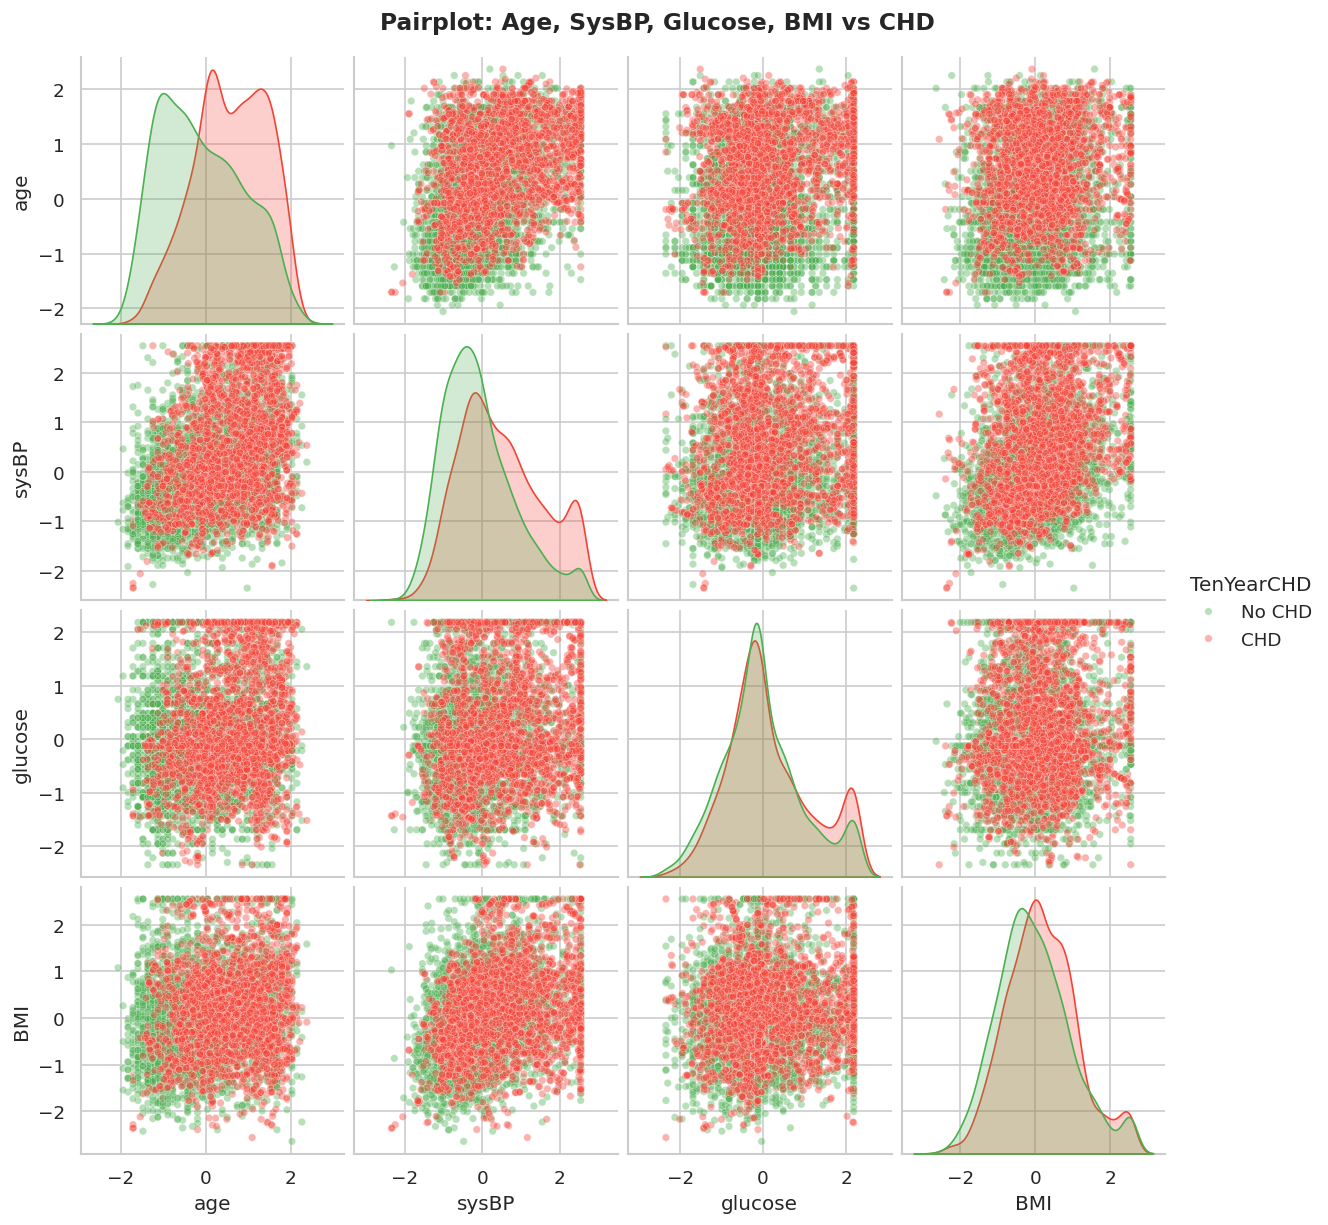

In [20]:
# Using 4 most impactful features to keep pairplot readable
pair_cols = ['age', 'sysBP', 'glucose', 'BMI', 'TenYearCHD']

pair_df = df[pair_cols].copy()
pair_df['TenYearCHD'] = pair_df['TenYearCHD'].map({0: 'No CHD', 1: 'CHD'})

g = sns.pairplot(
    pair_df,
    hue='TenYearCHD',
    palette={'No CHD': '#4CAF50', 'CHD': '#F44336'},
    diag_kind='kde',
    plot_kws={'alpha': 0.4, 's': 20}
)
g.figure.suptitle('Pairplot: Age, SysBP, Glucose, BMI vs CHD', y=1.02, fontsize=14, fontweight='bold')
plt.savefig('plot11_pairplot.png', bbox_inches='tight')
plt.show()

---
## Cell 16 — CHD Rate Summary Table (by Risk Factors)

In [21]:
print('='*50)
print('CHD POSITIVE RATE BY RISK FACTOR')
print('='*50)

risk_factors = {
    'Gender (Male=1)': 'male',
    'Smoker': 'currentSmoker',
    'On BP Medication': 'BPMeds',
    'Prevalent Hypertension': 'prevalentHyp',
    'Diabetes': 'diabetes',
    'Prevalent Stroke': 'prevalentStroke'
}

summary_rows = []
for label, col in risk_factors.items():
    rates = df.groupby(col)['TenYearCHD'].mean() * 100
    row = {'Risk Factor': label}
    for k, v in rates.items():
        row[f'Category={k}'] = f'{v:.1f}%'
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index('Risk Factor')
print(summary_df.to_string())

CHD POSITIVE RATE BY RISK FACTOR
                       Category=0 Category=1
Risk Factor                                 
Gender (Male=1)             50.1%      49.9%
Smoker                      51.1%      48.8%
On BP Medication            49.8%      56.4%
Prevalent Hypertension      43.3%      61.8%
Diabetes                    49.8%      58.8%
Prevalent Stroke            50.0%      52.2%


---
## Cell 17 — Key Insights Summary (For VIVA)

> **These 5 insights are derived from the EDA visualizations above.**

In [25]:
insights = """
╔══════════════════════════════════════════════════════════════════════════╗
║            KEY EDA INSIGHTS — CHD RISK ANALYSIS                         ║
╠══════════════════════════════════════════════════════════════════════════╣
║                                                                          ║
║  1. AGE is the strongest demographic predictor of CHD.                ║
║     Older patients show significantly higher CHD rates.                  ║
║     The violin plot shows CHD patients have a higher age distribution.   ║
║                                                                          ║
║  2. HIGH SYSTOLIC BP (sysBP) is a dominant risk indicator.            ║
║     CHD-positive patients consistently show elevated sysBP values.       ║
║     This is the top continuous correlate with TenYearCHD.                ║
║                                                                          ║
║  3. SMOKERS have a higher CHD rate than non-smokers.                  ║
║     The CHD rate increases progressively with cigarettes per day.        ║
║     Smoking is a significant behavioral risk factor.                     ║
║                                                                          ║
║  4. DIABETES patients show a disproportionately higher CHD rate.      ║
║     Glucose levels also show clear separation between CHD groups.        ║
║     Blood sugar control is critical for heart health.                    ║
║                                                                          ║
║  5. PREVALENT HYPERTENSION & BP MEDICATIONS                          ║
║     correlate strongly with CHD. Patients already on BP meds             ║
║     and those with hypertension show notably elevated CHD risk.          ║
║                                                                          ║
╚══════════════════════════════════════════════════════════════════════════╝
"""
print(insights)


╔══════════════════════════════════════════════════════════════════════════╗
║            KEY EDA INSIGHTS — CHD RISK ANALYSIS                         ║
╠══════════════════════════════════════════════════════════════════════════╣
║                                                                          ║
║  1. AGE is the strongest demographic predictor of CHD.                ║
║     Older patients show significantly higher CHD rates.                  ║
║     The violin plot shows CHD patients have a higher age distribution.   ║
║                                                                          ║
║  2. HIGH SYSTOLIC BP (sysBP) is a dominant risk indicator.            ║
║     CHD-positive patients consistently show elevated sysBP values.       ║
║     This is the top continuous correlate with TenYearCHD.                ║
║                                                                          ║
║  3. SMOKERS have a higher CHD rate than non-smokers.                  ║
║     Th

---
## Cell 18 — Save All Plots (Optional: ZIP for submission)

# Person 2